# 05_transition_plan_review.ipynb
**Author:** Emma McCallum  
**Purpose:** Review Bureau Veritas Exploitation's current reduction commitments 
and propose an illustrative two-stage improvement plan: inventory reconciliation 
first, then an emissions reduction scenario  
**Input:** `data/processed/emissions_long.csv`, `data/processed/five_firms_full.csv`  
**Output:** `figures/bv_waterfall.png`

## Important caveat

This notebook is an illustrative consulting exercise based on publicly available 
ADEME structured data and free-text fields. The reduction scenario presented is 
not a verified forecast. Lever savings are estimates informed by the reported 
emissions profile and the firm's own disclosed action plan, not independently 
verified primary data.

Bureau Veritas was selected because it combines the highest reported emissions 
in this dataset, the narrowest category coverage, and an unresolved tension 
between its methodology statement and its numerical reporting pattern. The full 
text disclosure reviewed in this notebook reveals a firm that is more strategically 
engaged than the structured export alone suggested. The central finding is therefore 
not that Bureau Veritas is a weak reporter. It is that its structured ADEME data 
does not fully reflect the depth of its actual climate commitments.

A credible transition plan requires a complete and reconciled inventory as its 
foundation. This notebook addresses that sequencing: inventory gaps first, 
reduction scenario second.

In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/five_firms_full.csv")

# Filter to Bureau Veritas most recent report
bv = df[df["Raison sociale"] == "BUREAU VERITAS EXPLOITATION"].sort_values(
    "Année de reporting", ascending=False
).iloc[0]

# Show all text fields that have content
for col in df.select_dtypes(include="str").columns:
    val = bv[col]
    if pd.notna(val) and str(val).strip() != "":
        print(f"\n{'='*50}")
        print(col)
        print('='*50)
        print(val)


Id
026ab04a-59fa-453e-8693-5d0fcf281f91

Méthode BEGES (V4,V5)
v5

Date de publication
2025-02-12

Type de structure
Entreprise

Raison sociale
BUREAU VERITAS EXPLOITATION

APE(NAF) associé
7120B

Libellé
Analyses, essais et inspections techniques

Nombre de salariés/d'agents de l'ensemble des SIREN déclarés sur ce bilan lors de l'année de reporting du bilan
Entre 2 000 et 4 999

Région
Île-de-France

Département
Hauts-de-Seine

Structure obligée
oui

SIREN des entités consolidées
449388669,422355982,521618579,399851609,392417689,821013455,790182786,320531171,501658421,824393169,382543924

Code NAF des entités consolidées
7120B,7120B,7022Z,7120B,7120B,7120B,7120B,8299Z,7120B,7120B,7112B

Départements des entités consolidées
13,33,92,92,92,92,92,92,92,92,35

Statut des entités consolidées
volontaire,volontaire,volontaire,volontaire,volontaire,volontaire,obligé,volontaire,volontaire,volontaire,volontaire

Mode de consolidation
Opérationnel

Assujetti DPEF/PCAET ?
oui

Lien DPEF/PCAET
["

## Bureau Veritas: full disclosure summary (translated)

**Organisation**
Technical analysis, testing and inspection services. Between 2,000 and 4,999 
employees. Headquartered in Hauts-de-Seine, Île-de-France. Consolidation method: 
operational control. 11 consolidated entities. Subject to mandatory BEGES reporting.

**2030 reduction target**
Minus 40% on Scopes 1 and 2, minus 25% on Scope 3.

**Reference year**
No reference year has been calculated. 2019 data was unavailable, so no baseline 
recalculation was possible. This is a significant limitation for tracking progress.

**Exclusions statement**
All emission posts were reviewed and evaluated based on available data at the time 
of the inventory. No materiality threshold was applied.

**Action plan highlights**
Governance: In 2023 a new Director of Procurement, Mobility and Real Estate was 
appointed with expanded responsibilities including sustainability. RSE contributors 
were designated by theme. A Mobility Committee was established with fleet 
electrification as one objective. Quarterly tracking of GHG KPIs introduced.

Fleet electrification (Scope 1, P1.2): Transition to 100% electric vehicles 
initiated in 2023. Target of 10% per year. Timeline 2025 to 2030.

Laboratory energy (Scopes 1 and 2): Energy performance audits of three French 
laboratories planned for 2025. Instrumentation and consumption monitoring to 
follow. Equipment optimisation planned for 2026 to 2027. The four French 
laboratories are in Cergy, Pessac, Villars, and Mulhouse.

Office energy efficiency (Scopes 1 and 2): Real estate master plan underway. 
Priority given to low-energy or LEED-certified buildings on lease renewals. Energy 
sobriety plan in place since 2022, limiting office temperature to 19°C in winter 
and 26°C in summer. Energy audits of sites with more than 100 workstations planned 
for 2025.

Refrigerant tracking (Scope 1, P1.4): Strengthened monitoring of refrigerant 
leaks across entities from 2024 to 2025.

Procurement and indirect emissions (Scope 3, P4.1 to P4.5): Awareness raising 
for procurement teams and financial controllers on GHG data availability. Training 
on responsible purchasing including circular economy and supply chain considerations. 
Timeline 2024 to 2026.

IT and cloud (Scope 2 and 3): Cloud storage prioritised using certified low-energy 
data centres. Low-energy IT equipment purchasing policy in place for many years.

**Results achieved since last inventory**
Electricity: Actions since 2018 delivered a saving of 391 tCO2e, of which 233 
tCO2e from reduced consumption and 158 tCO2e from switching to renewable 
electricity certificates (predominantly hydroelectric).

Vehicles: Fleet greening has been ongoing since 2017 including hybrid and electric 
vehicles and eco-driving training. However, business growth and headcount increases 
offset these savings and Scope 1 emissions did not decrease overall.

Waste: Selective sorting, recycling, and reuse programmes in place across all sites.

**Avoided emissions calculated**
P2.1 renewable electricity certificates: 160 tCO2e avoided.
P4.3 waste recycling and secondary materials: 49 tCO2e avoided.
P4.5 services sold to support client decarbonisation: impossible to quantify.

**Emission factors**
Base Carbone only. No version or year specified.

**Data sources**
Invoices, accounting data, meter readings, weighing records.

**Comparison with previous inventory**
Comparisons were made in the attached report for each post. Boundary expansion 
and headcount growth mean some comparisons are partial.

**Responsible for the report**
Gaele Morin, Project Manager QSSE (Quality, Health, Safety, Environment).
Contact: gaele.morin@bureauveritas.com

The report is owned by an environmental project manager rather than a sustainability 
director or CFO. This is relevant context because it may partly explain the gap 
between the depth of the action plan text and the thinness of the structured 
numerical data. The person responsible for filing may not have full visibility 
of all consumption data across 88 locations and 11 consolidated entities.

## Laboratory emissions: a domain-specific analysis

Bureau Veritas operates four analytical laboratories in France at Cergy, Pessac, 
Villars, and Mulhouse. Laboratory energy is identified as one of the five axes of 
their global climate transition plan, which reflects its materiality for a testing 
and inspection firm.

### Why laboratory energy is different from office energy

Laboratories consume far more energy per square metre than offices because safety, 
analytical quality, and accreditation requirements constrain what can be changed. 
Ventilation cannot simply be reduced without checking safety rules, method 
validation requirements, and sample integrity. Equipment cannot be switched off 
without considering instrument performance and analytical continuity. Changes to 
operating conditions in accredited laboratories may require revalidation before 
implementation. This makes laboratory decarbonisation slower and more technical 
than standard office energy reduction.

### The three dominant energy loads in analytical laboratories

**HVAC, ventilation, and fume hood exhaust** are typically the largest energy 
consumers. Laboratories require high air renewal rates for worker safety, which 
means they exhaust and replace large volumes of conditioned air continuously. 
Fume hoods in particular draw significant airflow even when not actively in use.

**Cold storage and thermal control** including freezers, refrigerators, ovens, 
drying cabinets, incubators, and climate-controlled rooms represent a large and 
often continuous load. Unlike office equipment, these systems cannot be shut down 
overnight without compromising sample integrity or analytical readiness.

**Instrumentation and support equipment** including GC, HPLC, ICP, spectrometers, 
pumps, compressors, autoclaves, water purification systems, and associated 
computers often run in standby or continuous mode. The direct electricity draw 
varies, but instruments also generate heat loads that increase cooling demand.

### Lever 1: Laboratory ventilation optimisation (P2.1, P4.1, Scope 1)

The highest impact intervention for laboratory energy is a ventilation and fume 
hood optimisation program. This could include auditing which fume hoods are 
actively needed, enforcing sash management, switching constant air volume systems 
to variable air volume where safety permits, reducing air change rates during 
unoccupied periods, and introducing occupancy-based ventilation controls.

This lever primarily reduces P2.1 if ventilation systems run on purchased 
electricity, and reduces Scope 1 if replacement air is heated using gas. It also 
reduces P4.1 indirectly as upstream energy emissions fall with lower consumption. 
Bureau Veritas has planned energy performance audits of their three operational 
laboratories for 2025, which is the correct first step before any optimisation.

### Lever 2: Green analytical chemistry program (P4.2, P4.4)

Solvents, reagents, standards, gases, columns, vials, and other consumables are 
not primarily a Scope 1 or Scope 2 issue. They sit mainly under purchased goods 
and services (P4.2) and hazardous waste treatment (P4.4). However, they are 
central to the footprint of analytical laboratories and are not addressed in 
Bureau Veritas's current action plan.

A green analytical chemistry program could include miniaturising sample 
preparation, reducing acetonitrile and halogenated solvent volumes, optimising 
HPLC and GC methods to reduce run times and solvent use, improving batch 
scheduling and instrument sharing, tightening chemical inventory management to 
reduce expired stock, and tracking hazardous waste by method or department.

This lever should be linked primarily to P4.2 and P4.4, with secondary benefits 
for P2.1 and P4.1 through reduced ventilation and equipment demand. It is not 
captured in Bureau Veritas's current structured or narrative reporting, which 
represents a gap in their transition plan.

### Key distinction

Laboratory energy reduction addresses Scope 1, Scope 2, and P4.1.
Solvent and consumable reduction addresses Scope 3, primarily P4.2 and P4.4.
These are two separate levers requiring different interventions, different data, 
and different ownership within the organisation.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load emissions data
emissions = pd.read_csv("../data/processed/emissions_long.csv")

# Filter to Bureau Veritas
bv = emissions[emissions["Raison sociale"] == "BUREAU VERITAS EXPLOITATION"].copy()

# Short label map from NB02
label_map = {
    "P1.1": "P1.1  Stationary combustion",
    "P1.2": "P1.2  Mobile combustion",
    "P1.3": "P1.3  Process emissions",
    "P1.4": "P1.4  Fugitive emissions",
    "P1.5": "P1.5  Biomass emissions",
    "P2.1": "P2.1  Electricity",
    "P2.2": "P2.2  Steam, heat, cooling",
    "P3.1": "P3.1  Upstream freight",
    "P3.2": "P3.2  Business travel",
    "P3.3": "P3.3  Visitor and client travel",
    "P3.4": "P3.4  Downstream freight",
    "P3.5": "P3.5  Employee commuting",
    "P4.1": "P4.1  Upstream energy",
    "P4.2": "P4.2  Purchased goods and services",
    "P4.3": "P4.3  Capital goods",
    "P4.4": "P4.4  Waste",
    "P4.5": "P4.5  Upstream leased assets",
    "P5.1": "P5.1  Use of sold products",
    "P5.2": "P5.2  End of life",
    "P5.3": "P5.3  Franchises",
    "P5.4": "P5.4  Downstream leased assets",
    "P6.1": "P6.1  Other indirect and investments",
}

bv["label"] = bv["beges_category"].map(label_map)

# Show only categories with positive values
bv_reported = bv[bv["tco2e"] > 0].sort_values("tco2e", ascending=False)

print("Bureau Veritas reported categories:")
print()
for _, row in bv_reported.iterrows():
    print(f"{row['label']:<45} {row['tco2e']:>10,.1f} tCO2e")

print()
print(f"Total reported: {bv_reported['tco2e'].sum():,.1f} tCO2e")
print(f"Categories with positive values: {len(bv_reported)} of 22")

Bureau Veritas reported categories:

P4.5  Upstream leased assets                    16,446.0 tCO2e
P4.1  Upstream energy                            4,912.0 tCO2e
P3.3  Visitor and client travel                  1,253.0 tCO2e
P4.2  Purchased goods and services                 395.0 tCO2e
P1.2  Mobile combustion                            136.0 tCO2e
P1.4  Fugitive emissions                            94.0 tCO2e
P4.3  Capital goods                                 62.0 tCO2e

Total reported: 23,298.0 tCO2e
Categories with positive values: 7 of 22


In [6]:
# Check the two totals
print("Sum from emissions_long.csv for Bureau Veritas:")
print(bv["tco2e"].sum())

print()
print("Sum of positive categories only:")
print(bv[bv["tco2e"] > 0]["tco2e"].sum())

print()
print("firm_summary.csv total:")
summary = pd.read_csv("../data/processed/firm_summary.csv")
bv_summary = summary[summary["Raison sociale"] == "BUREAU VERITAS EXPLOITATION"]
print(bv_summary[["Raison sociale", "grand_total"]].to_string(index=False))

Sum from emissions_long.csv for Bureau Veritas:
23298.0

Sum of positive categories only:
23298.0

firm_summary.csv total:
             Raison sociale  grand_total
BUREAU VERITAS EXPLOITATION      23298.0


## Bureau Veritas emissions profile

Total reported emissions: 23,298 tCO₂e across 7 of 22 BEGES categories.

The profile is highly concentrated. Two categories account for more than 90% of the reported total:

| Category | tCO₂e | Share |
|----------|-------|-------|
| P4.5 Upstream leased assets | 16,446 | 70.6% |
| P4.1 Upstream energy | 4,912 | 21.1% |
| P3.3 Visitor and client travel | 1,253 | 5.4% |
| P4.2 Purchased goods and services | 395 | 1.7% |
| P1.2 Mobile combustion | 136 | 0.6% |
| P1.4 Fugitive emissions | 94 | 0.4% |
| P4.3 Capital goods | 62 | 0.3% |

Business travel, employee commuting, and purchased electricity are all zero in the structured export. For a firm of this size, operating across 88 locations with staff travelling to client sites, these absences require explanation before any reduction pathway can be considered fully credible.

This concentration has an important implication for the transition plan analysis. A credible reduction scenario cannot focus only on visible operational measures such as fleet electrification or refrigerant tracking. It must first clarify what is included in P4.5, then prioritise energy demand reduction across offices, laboratories, leased assets, and technical facilities. The current action plan contains relevant measures, but NB05 must assess whether those measures are quantitatively aligned with the categories that drive the reported footprint.

The transition plan analysis therefore has two distinct parts: inventory reconciliation for zero or unexplained categories, and reduction lever modelling for categories where baseline data exists.

## Stage 1: Inventory reconciliation

Before modelling a reduction scenario, three zero categories require explanation. These are not necessarily reporting failures, but they cannot be left unaddressed in a credible transition plan.

### P2.1 Purchased electricity: zero

Bureau Veritas operates 88 locations and 4 laboratories. Purchased electricity should appear here unless it is captured elsewhere, netted against renewable electricity certificates, reported under another category, or omitted from the structured export. The action plan mentions that electricity certified from renewable origin has been procured since 2019, predominantly hydroelectric. The avoided emissions field confirms 160 tCO₂e avoided from renewable electricity certificates.

This suggests Bureau Veritas may be reporting a market-based Scope 2 figure of zero rather than a location-based figure, but the structured export does not clarify which basis was used. Under ESRS E1, Scope 2 emissions should be disclosed using both location-based and market-based methods. This zero therefore requires explicit methodological clarification.

Reconciliation action required: Disclose both location-based and market-based Scope 2 figures separately. State clearly which method was used in the structured export.

### P3.2 Business travel: zero

Bureau Veritas staff work primarily at client sites across 88 locations. The organisation description explicitly states that most activities are carried out at client premises. Business travel is therefore expected to be material. Its absence from the structured data is one of the most analytically significant gaps in the inventory.

The action plan does not explicitly address business travel measurement or reduction, which reinforces the concern that this category may not have been separately assessed.

Reconciliation action required: Measure and report business travel emissions using flight data, rail data, vehicle mileage, and hotel stays. This category may increase the reported total substantially once measured.

### P3.5 Employee commuting: zero

With between 2,000 and 4,999 employees across 88 locations, commuting emissions are likely to be non-trivial. The action plan mentions accessibility to public transport as a site selection criterion, which suggests awareness of commuting as a factor but does not confirm measurement.

Reconciliation action required: Conduct a commuting survey or use national average data to estimate commuting emissions. Link the estimate explicitly to P3.5 in the next reporting cycle.

### What reconciliation means for the baseline

Measuring business travel and commuting will likely increase the reported total before it decreases. This is normal and expected in carbon accounting when inventory coverage expands. A higher but more complete baseline is more credible than a lower but incomplete one. The 23,298 tCO₂e figure should therefore be treated as a floor, not a ceiling.

In [7]:
# Illustrative 2030 reduction scenario for Bureau Veritas
# Lever estimates are informed by the disclosed action plan and positive baseline categories
# They are not verified forecasts
# Categories with zero structured baseline values are excluded from the waterfall
# and treated separately as inventory reconciliation priorities

baseline = 23298.0

levers = [
    {
        "label": "Leased asset\ndecarbonisation (P4.5)",
        "saving": 3289,
        "note": "20% reduction on 16,446 tCO2e upstream leased assets"
    },
    {
        "label": "Laboratory and energy\noptimisation (P4.1)",
        "saving": 982,
        "note": "20% reduction on 4,912 tCO2e upstream energy"
    },
    {
        "label": "Visitor and client travel\nmanagement (P3.3)",
        "saving": 313,
        "note": "25% reduction on 1,253 tCO2e visitor and client travel"
    },
    {
        "label": "Procurement and\nsupplier engagement (P4.2)",
        "saving": 118,
        "note": "30% reduction on 395 tCO2e purchased goods and services"
    },
    {
        "label": "Fleet electrification\n(P1.2)",
        "saving": 95,
        "note": "70% reduction on 136 tCO2e mobile combustion"
    },
    {
        "label": "Refrigerant\nmanagement (P1.4)",
        "saving": 47,
        "note": "50% reduction on 94 tCO2e fugitive emissions"
    },
    {
        "label": "Capital goods\nprocurement (P4.3)",
        "saving": 12,
        "note": "20% reduction on 62 tCO2e capital goods"
    },
]

total_saving = sum(l["saving"] for l in levers)
target_2030 = baseline - total_saving

print(f"Baseline: {baseline:,.0f} tCO2e")
print(f"Total estimated saving: {total_saving:,.0f} tCO2e")
print(f"Illustrative 2030 total: {target_2030:,.0f} tCO2e")
print(f"Reduction: {total_saving/baseline*100:.1f}%")
print()
for l in levers:
    print(f"{l['saving']:>6} tCO2e  {l['label'].replace(chr(10), ' ')}")

Baseline: 23,298 tCO2e
Total estimated saving: 4,856 tCO2e
Illustrative 2030 total: 18,442 tCO2e
Reduction: 20.8%

  3289 tCO2e  Leased asset decarbonisation (P4.5)
   982 tCO2e  Laboratory and energy optimisation (P4.1)
   313 tCO2e  Visitor and client travel management (P3.3)
   118 tCO2e  Procurement and supplier engagement (P4.2)
    95 tCO2e  Fleet electrification (P1.2)
    47 tCO2e  Refrigerant management (P1.4)
    12 tCO2e  Capital goods procurement (P4.3)


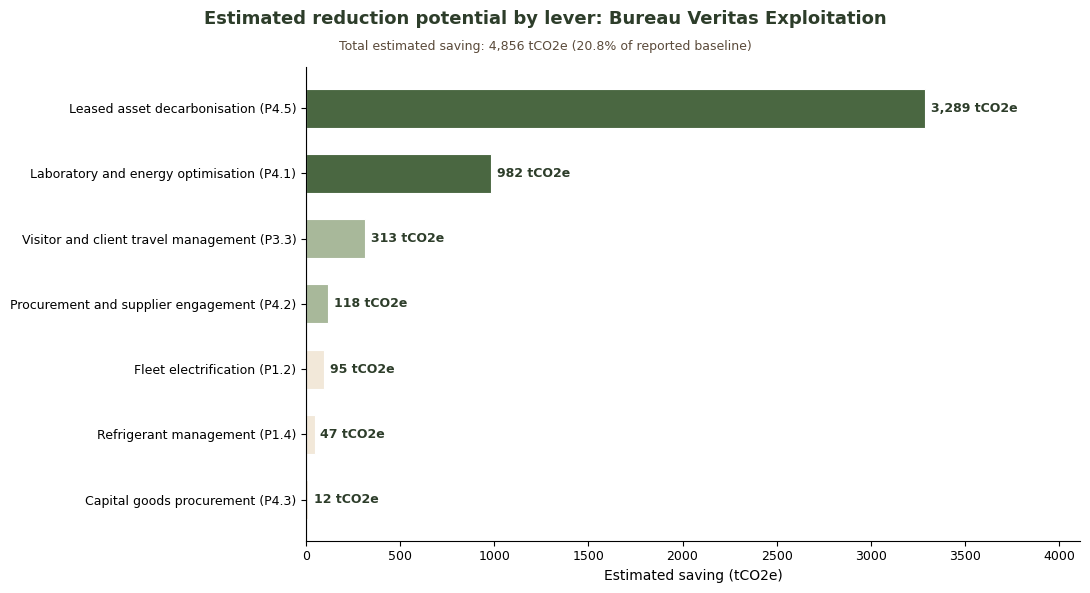

Saved.


In [9]:
fig, ax = plt.subplots(figsize=(11, 6))

# Sort levers by saving descending
sorted_levers = sorted(levers, key=lambda x: x["saving"], reverse=True)

labels = [l["label"].replace("\n", " ") for l in sorted_levers]
savings = [l["saving"] for l in sorted_levers]

colours = ["#4a6741" if s > 500 else "#a8b89a" if s > 100 else "#f2e8d9"
           for s in savings]
text_colours = ["white" if s > 500 else "#2d3d2a" for s in savings]

bars = ax.barh(labels, savings, color=colours, edgecolor="white",
               linewidth=0.8, height=0.6)

for bar, saving, tc in zip(bars, savings, text_colours):
    ax.text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
            f"{saving:,.0f} tCO2e", va="center", fontsize=9,
            color="#2d3d2a", fontweight="bold")

ax.set_xlabel("Estimated saving (tCO2e)", fontsize=10)
ax.invert_yaxis()
ax.set_xlim(0, max(savings) * 1.25)
ax.axvline(x=0, color="#888888", linewidth=0.8)
ax.tick_params(axis="y", labelsize=9)
ax.tick_params(axis="x", labelsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(0.5, 0.98,
         "Estimated reduction potential by lever: Bureau Veritas Exploitation",
         ha="center", va="top", fontsize=13, fontweight="bold", color="#2d3d2a")
fig.text(0.5, 0.93,
         f"Total estimated saving: {total_saving:,.0f} tCO2e ({total_saving/baseline*100:.1f}% of reported baseline)",
         ha="center", va="top", fontsize=9, color="#5a4a3a")

plt.tight_layout(rect=[0, 0, 1, 0.91])
plt.savefig("../figures/bv_levers.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved.")

## Interpretation: lever prioritisation

The lever analysis shows that the estimated reduction potential is highly 
concentrated. Leased asset decarbonisation accounts for approximately 3,289 
tCO2e of the modelled savings, while laboratory and energy optimisation accounts 
for 982 tCO2e. Together these two levers represent about 88% of the total 
estimated reduction potential in the scenario.

This means that Bureau Veritas's transition plan cannot rely mainly on smaller 
visible actions such as fleet electrification or refrigerant management. Those 
actions are operationally relevant, but they do not address the main reported 
emissions drivers. A credible 2030 plan would need to clarify the composition 
of P4.5 and then set quantified actions for leased assets, laboratories, offices, 
and technical facilities.

The scenario achieves an estimated 4,856 tCO2e reduction, equal to 20.8% of 
the reported baseline. This remains an illustrative estimate only, because it 
excludes categories with zero structured baselines such as business travel, 
employee commuting, and purchased electricity. If those categories are measured 
in future reporting cycles, the baseline may increase before reductions become 
visible.

## Consulting recommendation

Bureau Veritas has the elements of a real climate strategy. The action plan is structured, covers relevant categories, and includes a quantified 2030 target. The main problem is not the presence of ambition, but the connection between ambition, inventory quality, and quantified reduction levers.

Three actions would materially strengthen the transition plan:

**1. Reconcile the inventory.** Measure and report business travel, employee 
commuting, and purchased electricity separately. State clearly whether Scope 2 
is reported on a location-based or market-based basis. A more complete inventory 
is the prerequisite for a credible reduction pathway.

**2. Clarify P4.5.** Upstream leased assets represent 70% of the reported 
footprint. The transition plan cannot be taken seriously without explaining what 
this category contains and what specific actions will reduce it.

**3. Quantify the action plan.** The current plan lists initiatives, timelines, 
and indicators, but does not translate these into expected tCO2e reductions by 
category. Connecting each action to a measurable emissions impact would make 
the plan significantly more credible and trackable.

The illustrative scenario presented in this notebook achieves a 20.8% reduction 
from the reported baseline. Reaching the disclosed 25% reported Scope 3 target would 
require stronger action on P4.5 and P4.1, and would also require measuring the 
currently zero categories to establish a complete baseline.

In [11]:
import os

outputs = [
    "../figures/bv_levers.png",
]

for path in outputs:
    exists = os.path.exists(path)
    size = os.path.getsize(path) if exists else 0
    print(f"{'OK' if exists else 'MISSING'}  {path}  ({size:,} bytes)")

OK  ../figures/bv_levers.png  (90,541 bytes)
